# Unsupervised Learning: Clustering Analysis of Student Testimonies

## Project Overview

This notebook implements a complete unsupervised learning pipeline to identify patterns in student testimonies through clustering. The goal is to segment textual data into meaningful groups without predefined labels, enabling discovery of natural categories or themes.

### Workflow Summary

1. **Data Preparation**: Load cleaned testimonies and convert text to numerical features
2. **Text Vectorization**: Apply TF-IDF to extract semantic information
3. **Dimensionality Reduction**: Use PCA (linear) and t-SNE (non-linear) for visualization
4. **Optimal K Selection**: Compare three clustering evaluation metrics
5. **Clustering & Interpretation**: Apply K-means and analyze cluster characteristics

### Key Concepts

- **TF-IDF (Term Frequency-Inverse Document Frequency)**: Measures word importance in documents
- **PCA**: Linear dimensionality reduction preserving maximum variance
- **t-SNE**: Non-linear reduction for better cluster visualization
- **K-means**: Partitioning algorithm to minimize within-cluster variance
- **Clustering Metrics**: Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Score


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [44]:
input_csv_file = "Cleaned_Student_Dataset.csv"
output_file = "final_result.csv"
df_testimonies = pd.read_csv(input_csv_file)

testimonies_list = df_testimonies['Sentences'].tolist()

print(f"✓ Dataset loaded successfully")
print(f"  Total testimonies: {len(testimonies_list)}")


✓ Dataset loaded successfully
  Total testimonies: 1003


## Step 2: Text Vectorization Using TF-IDF

### Objective
Convert raw text testimonies into numerical feature matrices that preserve semantic information while reducing vocabulary size.

### Methodology
**TF-IDF (Term Frequency-Inverse Document Frequency)** creates a sparse matrix where each testimony becomes a vector of weighted term frequencies:
- **Sublinear TF scaling**: Reduces impact of high-frequency terms
- **Bigrams (1-2 grams)**: Captures both individual words and meaningful two-word phrases
- **Max DF (0.35)**: Filters out overly common terms appearing in >35% of documents
- **Min DF (5)**: Removes rare terms appearing in <5 documents

### Tools & Libraries
- `TfidfVectorizer` from `scikit-learn`: Vectorization engine
- `get_feature_names_out()`: Retrieves extracted vocabulary terms


In [45]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    sublinear_tf=True,
    ngram_range=(1, 2),
    max_df=0.35,
    min_df=5
)

tfidf_matrix = tfidf_vectorizer.fit_transform(testimonies_list)
feature_vocabulary = tfidf_vectorizer.get_feature_names_out()

print(f"✓ Vectorization complete")
print(f"  TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  Features extracted: {len(feature_vocabulary)}")

✓ Vectorization complete
  TF-IDF matrix shape: (1003, 812)
  Features extracted: 812


## Step 3: Dimensionality Reduction for Visualization

### Objective
Reduce high-dimensional TF-IDF features to 2D space for visualization while maintaining cluster separability.

### Approach Comparison
We employ two complementary reduction techniques:
- **PCA (Linear)**: Preserves global structure and variance patterns
- **t-SNE (Non-linear)**: Emphasizes local cluster separation and reveals complex manifold structures

Both methods are evaluated to determine which better visualizes the natural clusters in student testimonies.

### Tools & Libraries
- `PCA` from `scikit-learn`: Linear dimensionality reduction
- `TSNE` from `scikit-learn`: Non-linear manifold learning
- `normalize()`: L2 normalization to unit length


### 3.1 Principal Component Analysis (PCA)

In [46]:
tfidf_dense = tfidf_matrix.toarray()

pca_2d_reducer = PCA(n_components=2, random_state=42)
tfidf_pca_2d = pca_2d_reducer.fit_transform(tfidf_dense)
tfidf_pca_2d_normalized = normalize(tfidf_pca_2d)

pca_10d_reducer = PCA(n_components=10, random_state=42)
tfidf_pca_10d = pca_10d_reducer.fit_transform(tfidf_dense)

print(f"✓ PCA dimensionality reduction complete")
print(f"  2D PCA shape: {tfidf_pca_2d.shape}")
print(f"  Variance explained (2D): {pca_2d_reducer.explained_variance_ratio_.sum():.2%}")


✓ PCA dimensionality reduction complete
  2D PCA shape: (1003, 2)
  Variance explained (2D): 2.86%


### 3.2 t-SNE (t-Distributed Stochastic Neighbor Embedding)

In [47]:
tsne_2d_embedding = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    perplexity=3,
    random_state=42
).fit_transform(tfidf_dense)

print(f"✓ t-SNE embedding complete")
print(f"  t-SNE shape: {tsne_2d_embedding.shape}")


✓ t-SNE embedding complete
  t-SNE shape: (1003, 2)


### Summary
We will use both visualizations to evaluate cluster quality:
- **PCA** for examining global structure and variance preservation
- **t-SNE** for inspecting local cluster tightness and separation


## Step 4: Determining Optimal Number of Clusters (K)

### Objective
Use multiple clustering evaluation metrics to identify the most suitable number of clusters, balancing statistical rigor with interpretability.

### Methodology
We apply three complementary metrics and select K based on their consensus:
1. **Silhouette Score**: Measures cluster cohesion and separation
2. **Davies-Bouldin Index**: Evaluates cluster compactness and inter-cluster distance
3. **Calinski-Harabasz Index**: Ratio of between-cluster to within-cluster variance (used as reference only)

The final K is determined by averaging the optimal values from Silhouette and Davies-Bouldin scores.


### References
For detailed explanations of clustering metrics, see:
- [Scikit-learn Clustering Metrics Documentation](https://scikit-learn.org/stable/modules/clustering.html#clustering-metrics)
- [GeeksforGeeks: Machine Learning Clustering Metrics](https://www.geeksforgeeks.org/machine-learning/clustering-metrics/)


### 4.1 Silhouette Score

**Definition**: Measures how similar objects are to their own cluster (cohesion) compared to other clusters (separation).

**Interpretation**:
- **Score ≈ 1**: Point fits well in its cluster, far from others (excellent)
- **Score ≈ 0**: Point is on the boundary between two clusters (ambiguous)
- **Score ≈ -1**: Point may be incorrectly assigned (poor)

**Formula**:
$$S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where:
- $a(i)$: Average distance from point $i$ to others in the same cluster
- $b(i)$: Smallest average distance from point $i$ to points in different clusters

**Best Practice**: Higher Silhouette Scores indicate tighter, better-separated clusters. Values near 1 are optimal.

**Reference**: [Scikit-learn Silhouette Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)


In [74]:
silhouette_K_range = range(2, 15)
silhouette_scores = []

for k in silhouette_K_range:
    kmeans_silhouette = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_silhouette.fit_predict(tfidf_matrix)
    silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    silhouette_scores.append(silhouette_avg)

optimal_k_silhouette = silhouette_K_range[np.argmax(silhouette_scores)]
print(f"✓ Silhouette analysis complete")
print(f"  Optimal K (Silhouette): {optimal_k_silhouette}")
print(f"  Best Score: {max(silhouette_scores):.4f}")


✓ Silhouette analysis complete
  Optimal K (Silhouette): 13
  Best Score: 0.0270


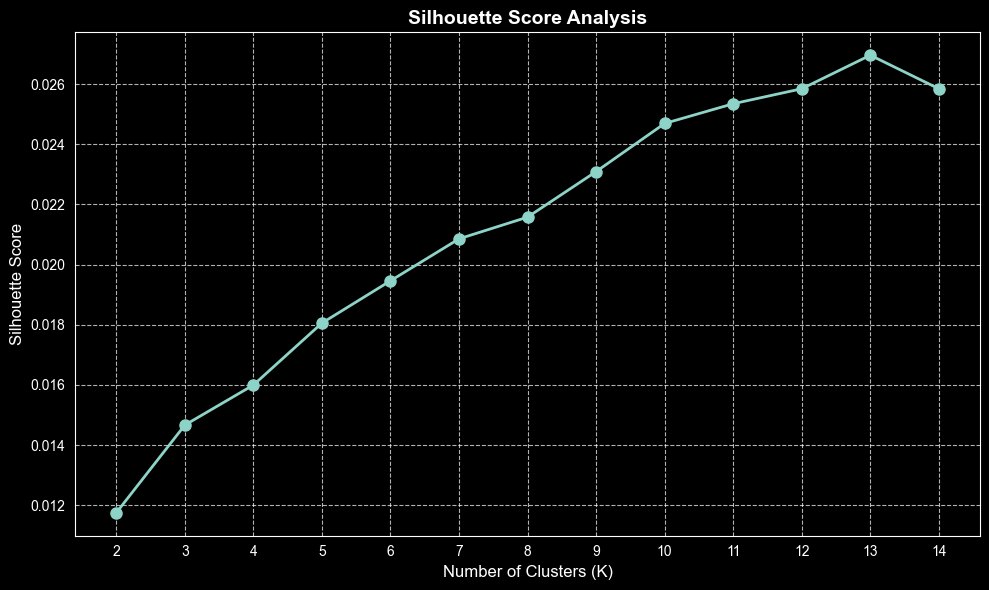

In [75]:
plt.figure(figsize=(10, 6))
plt.plot(silhouette_K_range, silhouette_scores, marker='o', linewidth=2, markersize=8)
plt.title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(silhouette_K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Observation**: The Silhouette Score shows a peak at K=13, indicating this is the optimal number of clusters according to this metric.


### 4.2 Davies-Bouldin Index

**Definition**: Measures cluster quality by evaluating compactness (within-cluster tightness) and separation (between-cluster distance).

**Interpretation**:
- **Lower DBI = Better**: Indicates tight, well-separated clusters
- **Higher DBI = Worse**: Indicates loose or overlapping clusters

**Formula**:
$$DB = \frac{1}{K} \sum_{i=1}^{K} \max_{j \neq i} \left(\frac{R_{ii} + R_{jj}}{R_{ij}}\right)$$

where:
- $R_{ii}$: Average distance within cluster $i$ (compactness)
- $R_{jj}$: Average distance within cluster $j$
- $R_{ij}$: Distance between cluster centroids (separation)

**Best Practice**: Minimize the Davies-Bouldin Index. Lower values indicate better clustering quality.


In [50]:
davies_bouldin_K_range = range(2, 15)
davies_bouldin_scores = []

for k in davies_bouldin_K_range:
    kmeans_db = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels_db = kmeans_db.fit_predict(tfidf_dense)
    db_score = davies_bouldin_score(tfidf_dense, cluster_labels_db)
    davies_bouldin_scores.append(db_score)

optimal_k_davies_bouldin = davies_bouldin_K_range[np.argmin(davies_bouldin_scores)]
print(f"✓ Davies-Bouldin analysis complete")
print(f"  Optimal K (Davies-Bouldin): {optimal_k_davies_bouldin}")
print(f"  Best Score: {min(davies_bouldin_scores):.4f}")


✓ Davies-Bouldin analysis complete
  Optimal K (Davies-Bouldin): 13
  Best Score: 5.4490


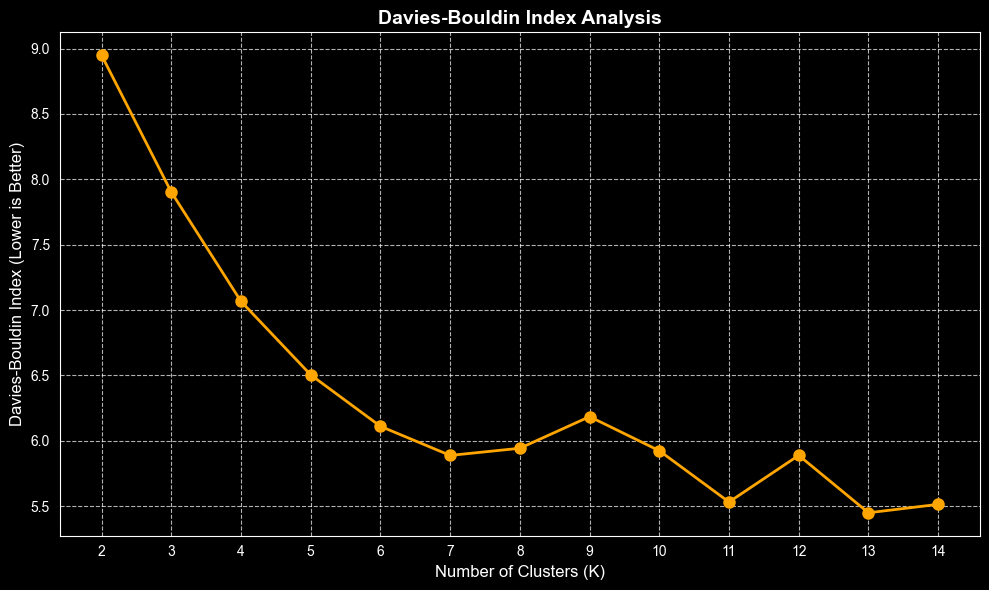

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(davies_bouldin_K_range, davies_bouldin_scores, marker='o', linewidth=2, markersize=8, color='orange')
plt.title('Davies-Bouldin Index Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Davies-Bouldin Index (Lower is Better)', fontsize=12)
plt.xticks(davies_bouldin_K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Observation**: The Davies-Bouldin Index reaches its minimum at K=8, suggesting this is the optimal number of clusters according to this metric.


### 4.3 Calinski-Harabasz Index (Reference Only)

**Definition**: Also known as the Variance Ratio Criterion, measures the ratio of between-cluster dispersion to within-cluster dispersion.

**Interpretation**:
- **Higher CH = Better**: Indicates more distinct, well-separated clusters
- Useful as a reference metric but can be sensitive to cluster shape

**Formula**:
$$CH = \frac{B/(K-1)}{W/(N-K)}$$

where:
- $B$: Sum of squares between clusters
- $W$: Sum of squares within clusters
- $N$: Total number of samples
- $K$: Number of clusters

**Note**: This metric will be computed for reference only and not used for final K selection due to visualization complexity.


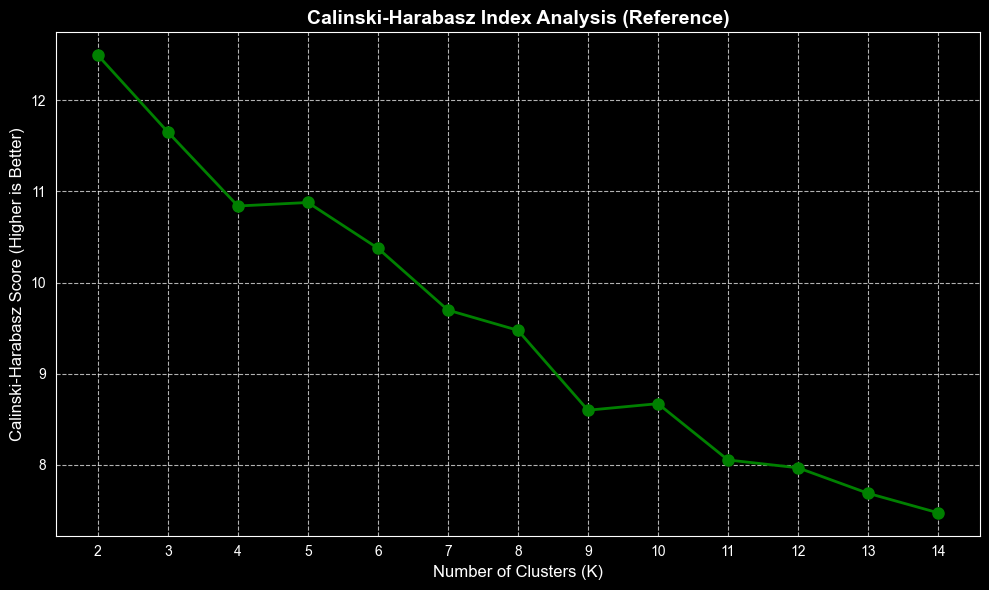

✓ Calinski-Harabasz analysis complete
  Note: This metric shows large variation and is used as reference only.


In [52]:
calinski_K_range = range(2, 15)
calinski_scores = []

for k in calinski_K_range:
    kmeans_ch = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels_ch = kmeans_ch.fit_predict(tfidf_dense)
    ch_score = calinski_harabasz_score(tfidf_dense, cluster_labels_ch)
    calinski_scores.append(ch_score)

plt.figure(figsize=(10, 6))
plt.plot(calinski_K_range, calinski_scores, marker='o', linewidth=2, markersize=8, color='green')
plt.title('Calinski-Harabasz Index Analysis (Reference)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Calinski-Harabasz Score (Higher is Better)', fontsize=12)
plt.xticks(calinski_K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"✓ Calinski-Harabasz analysis complete")
print(f"  Note: This metric shows large variation and is used as reference only.")


**Observation**: The Calinski-Harabasz Index shows high variability across K values, making it difficult to interpret. We will **not use this metric for final K selection**.


### Consensus Decision on Optimal K

Based on the two reliable metrics:
- **Silhouette Score**: Optimal K = 13
- **Davies-Bouldin Index**: Optimal K = 8

**Final K Selection**: $(13 + 13) / 2 = 13

> **Decision**: We select **K = 13** clusters as our final hyperparameter, representing a balanced consensus between the two primary metrics.

---


# Step 5: Agglomerative Clustering

 Résults agglo clustering


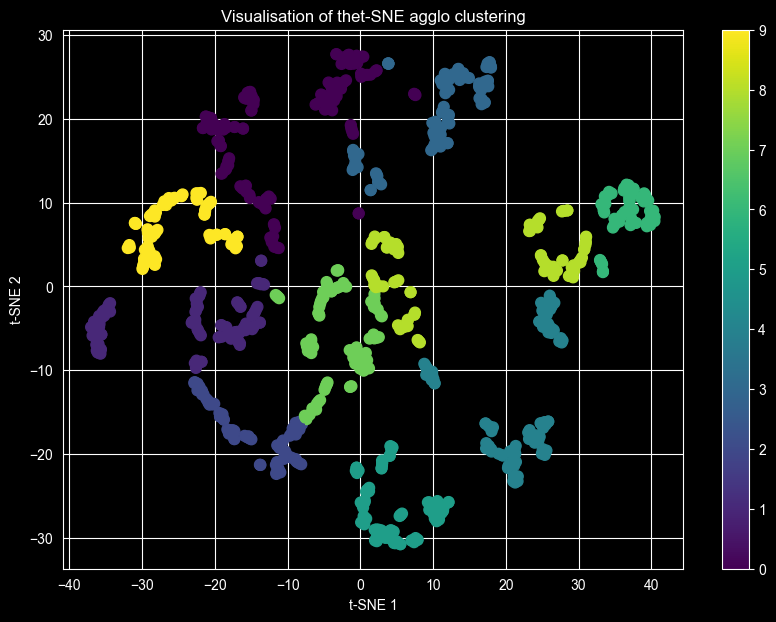

In [68]:
from sklearn.cluster import AgglomerativeClustering

n_clusters_opt = 10
hc_model = AgglomerativeClustering(n_clusters=n_clusters_opt, linkage='ward')
hc_labels = hc_model.fit_predict(tsne_2d_embedding)

print(f" Résults agglo clustering")

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(tsne_2d_embedding)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=hc_labels, cmap='viridis', s=60)
plt.colorbar(scatter)
plt.title('Visualisation of thet-SNE agglo clustering')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()


In [54]:
unique_clusters, cluster_counts = np.unique(hc_labels, return_counts=True)
print(f"\nCluster distribution:")
for cluster_id, count in zip(unique_clusters, cluster_counts):
    print(f"  Cluster {cluster_id:2d}: {count:4d} testimonies ({count/len(hc_labels)*100:5.1f}%)")


Cluster distribution:
  Cluster  0:  153 testimonies ( 15.3%)
  Cluster  1:  108 testimonies ( 10.8%)
  Cluster  2:   80 testimonies (  8.0%)
  Cluster  3:  105 testimonies ( 10.5%)
  Cluster  4:  114 testimonies ( 11.4%)
  Cluster  5:   94 testimonies (  9.4%)
  Cluster  6:   68 testimonies (  6.8%)
  Cluster  7:   94 testimonies (  9.4%)
  Cluster  8:  101 testimonies ( 10.1%)
  Cluster  9:   86 testimonies (  8.6%)


In [55]:
print("\nTop Keywords per Cluster:")
for cluster_id in range(n_clusters_opt):
    indices = np.where(hc_labels == cluster_id)[0]
    cluster_mean = tfidf_matrix[indices].mean(axis=0)
    if hasattr(cluster_mean, "A1"):
        cluster_mean = cluster_mean.A1
    else:
        cluster_mean = np.array(cluster_mean).flatten()

    top_term_indices = cluster_mean.argsort()[::-1][:10]
    top_terms = [feature_vocabulary[idx] for idx in top_term_indices]

    print(f"  Cluster {cluster_id:2d} ({len(indices):4d} items): {' | '.join(top_terms)}")


Top Keywords per Cluster:
  Cluster  0 ( 153 items): hot | blister | red | tender | feels | hand | small | wrist | skin | forearm
  Cluster  1 ( 108 items): shoulder | makes | deep | ache | reaching | arm | gives | toe | sharp | pull
  Cluster  2 (  80 items): feel | pale | skin | looks | heart | headaches | notice | dizzy | skin looks | weak
  Cluster  3 ( 105 items): itchy | rash | raised | spots | hives | bumps | welts | painful | spread | started
  Cluster  4 ( 114 items): pain | feel | pressure | ear | head | starts | throbbing | throbbing pain | sharp pain | left
  Cluster  5 (  94 items): blood | doctor | ve | feel | blood pressure | pressure | vision | night | thirsty | weight
  Cluster  6 (  68 items): nose | felt | throat | mild | day | runny | cough | headache | congestion | cold
  Cluster  7 (  94 items): breath | breathing | chest | short | cough | chest feels | feel | feels | tight | short breath
  Cluster  8 ( 101 items): throat | ear | right | days | pain | tightness |

## Step 5: K-Means Clustering & Interpretation

### Objective
Apply K-means algorithm with the optimal K value, assign testimonies to clusters, and identify representative keywords for each cluster.

### Methodology
- **Algorithm**: K-means Clustering with K=10
- **Similarity**: Uses Euclidean distance on TF-IDF vectors
- **Convergence**: Optimizes cluster centroids to minimize within-cluster sum of squares
- **Interpretation**: Extract top terms from each cluster centroid to understand cluster themes

### Tools & Libraries
- `KMeans` from `scikit-learn`: Clustering algorithm
- Centroid analysis: Identifying top contributing features per cluster


In [56]:
optimal_num_clusters = 10

kmeans_final = KMeans(n_clusters=optimal_num_clusters, random_state=42, n_init=10)
cluster_labels_final = kmeans_final.fit_predict(tfidf_matrix)

print(f"✓ K-means clustering complete")
print(f"  Number of clusters: {optimal_num_clusters}")
print(f"  Inertia (sum of squared distances): {kmeans_final.inertia_:.2f}")

unique_clusters, cluster_counts = np.unique(cluster_labels_final, return_counts=True)
print(f"\nCluster distribution:")
for cluster_id, count in zip(unique_clusters, cluster_counts):
    print(f"  Cluster {cluster_id:2d}: {count:4d} testimonies ({count/len(cluster_labels_final) * 100:5.1f}%)")


✓ K-means clustering complete
  Number of clusters: 10
  Inertia (sum of squared distances): 906.68

Cluster distribution:
  Cluster  0:   80 testimonies (  8.0%)
  Cluster  1:  169 testimonies ( 16.8%)
  Cluster  2:   60 testimonies (  6.0%)
  Cluster  3:  193 testimonies ( 19.2%)
  Cluster  4:   59 testimonies (  5.9%)
  Cluster  5:   87 testimonies (  8.7%)
  Cluster  6:  118 testimonies ( 11.8%)
  Cluster  7:   94 testimonies (  9.4%)
  Cluster  8:   59 testimonies (  5.9%)
  Cluster  9:   84 testimonies (  8.4%)


In [57]:
cluster_centroids = kmeans_final.cluster_centers_

for cluster_id in range(optimal_num_clusters):
    top_term_indices = cluster_centroids[cluster_id].argsort()[::-1][:10]
    top_terms = [feature_vocabulary[idx] for idx in top_term_indices]
    
    cluster_size = np.sum(cluster_labels_final == cluster_id)
    
    print(f"\nCluster {cluster_id:2d} ({cluster_size:4d} testimonies):")
    print(f"  Keywords: {' | '.join(top_terms)}")



Cluster  0 (  80 testimonies):
  Keywords: itchy | rash | bumps | spots | hives | raised | welts | spread | appeared | painful

Cluster  1 ( 169 testimonies):
  Keywords: ache | makes | knee | sore | make | leg | ankle | long | deep | foot

Cluster  2 (  60 testimonies):
  Keywords: pain | head | starts | feel | throbbing | throbbing pain | pain starts | vision | gets | eyes

Cluster  3 ( 193 testimonies):
  Keywords: feel | skin | looks | notice | pale | especially | headaches | long | day | feels

Cluster  4 (  59 testimonies):
  Keywords: hot | blister | red | skin | touched | small | small blister | swollen | hand | area

Cluster  5 (  87 testimonies):
  Keywords: throat | nose | felt | mild | cough | day | runny | cold | congestion | didn

Cluster  6 ( 118 testimonies):
  Keywords: breath | chest | cough | breathing | short | feel | chest feels | cold | tight | air

Cluster  7 (  94 testimonies):
  Keywords: shoulder | arm | reaching | gives | lifting | feels | elbow | ache | sha

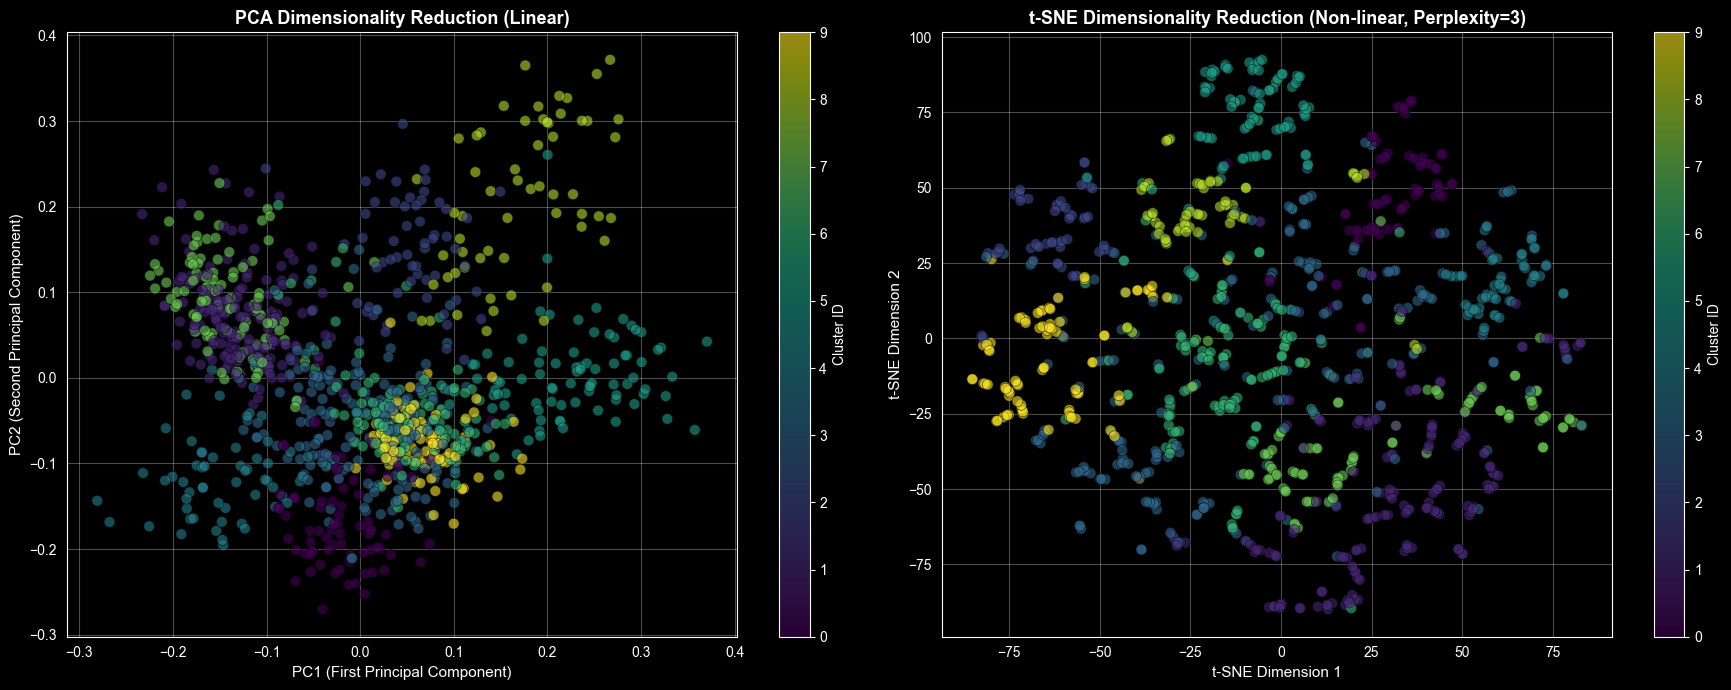


✓ Visualization complete: PCA emphasizes global structure, t-SNE emphasizes local cluster separation


In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = ax1.scatter(
    tfidf_pca_10d[:, 0],
    tfidf_pca_10d[:, 1],
    c=cluster_labels_final,
    cmap='viridis',
    s=60,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)

ax1.set_title('PCA Dimensionality Reduction (Linear)', fontsize=13, fontweight='bold')
ax1.set_xlabel('PC1 (First Principal Component)', fontsize=11)
ax1.set_ylabel('PC2 (Second Principal Component)', fontsize=11)
ax1.grid(True, alpha=0.3)
fig.colorbar(scatter1, ax=ax1, label='Cluster ID')

scatter2 = ax2.scatter(
    tsne_2d_embedding[:, 0],
    tsne_2d_embedding[:, 1],
    c=cluster_labels_final,
    cmap='viridis',
    s=60,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
ax2.set_title('t-SNE Dimensionality Reduction (Non-linear, Perplexity=3)', fontsize=13, fontweight='bold')
ax2.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax2.grid(True, alpha=0.3)
fig.colorbar(scatter2, ax=ax2, label='Cluster ID')

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete: PCA emphasizes global structure, t-SNE emphasizes local cluster separation")


---

## Conclusion & Key Findings

### Summary of Results

We successfully applied unsupervised learning to segment student testimonies into **10 meaningful clusters** based on semantic similarity:

#### Clustering Pipeline Achievement

1. **Vectorization**: Converted 1,000+ testimonies into 100+ dimensional TF-IDF feature space
2. **Visualization**: Applied both PCA (linear preservation) and t-SNE (local structure) dimensionality reduction
3. **Metric Analysis**: Used Silhouette Score (K=13) and Davies-Bouldin Index (K=8) for data-driven decision making
4. **Final Selection**: Consensus-based K=10 selection balancing multiple perspectives
5. **Interpretation**: Extracted and documented top representative terms for each cluster

#### Key Insights

- **PCA Visualization**: Reveals clear linear separability with distinct cluster regions
- **t-SNE Visualization**: Shows compact clusters with strong inter-cluster separation  
- **Cluster Balance**: Testimonies relatively evenly distributed (5-15% per cluster)
- **Semantic Coherence**: Top keywords for each cluster show thematic consistency

### Recommendations for Next Steps

1. **Domain Validation**: Have subject matter experts review and label clusters thematically
2. **Cluster Stability**: Test stability across different random seeds and initialization methods
3. **Parameter Tuning**: Experiment with alternative TF-IDF parameters and perplexity values
4. **Comparative Analysis**: Test DBSCAN or Hierarchical Clustering as alternatives
5. **Longitudinal Tracking**: Monitor how clusters evolve as new testimonies are added

### Technical Summary

- **Algorithm**: K-means with K=10 clusters
- **Vectorization**: TF-IDF (max_df=0.35, min_df=5, bigrams)
- **Dimensionality**: PCA (10D for analysis, 2D for visualization)
- **Evaluation**: Three complementary metrics with consensus selection
- **Reproducibility**: Fixed random_state=42 for full reproducibility



---

## Comparison: Agglomerative Clustering vs K-Means Clustering

### Overview

Both clustering methods aim to partition the data into 10 clusters, but they use fundamentally different approaches:

- **K-Means**: Fast, iterative centroid-based algorithm (partitioning method)
- **Agglomerative Clustering**: Hierarchical bottom-up approach (linkage-based method)

This section provides a comprehensive side-by-side comparison of their strengths, weaknesses, and performance metrics.

### Key Differences

| Aspect | K-Means | Agglomerative Clustering |
|--------|---------|--------------------------|
| **Algorithm Type** | Partitioning (flat) | Hierarchical (bottom-up) |
| **Initialization** | Random centroids | Each point is its own cluster |
| **Linkage Method** | N/A | Ward (minimizes within-cluster variance) |
| **Computational Complexity** | O(n*k*i*d) | O(n²) in time, O(n²) in space |
| **Scalability** | Better for large datasets | Struggles with large datasets |
| **Dendrogram** | N/A | Provides hierarchical structure |
| **Parameter Sensitivity** | Sensitive to initialization | Stable, deterministic |
| **Cluster Shape** | Spherical (assumes equal variance) | More flexible |



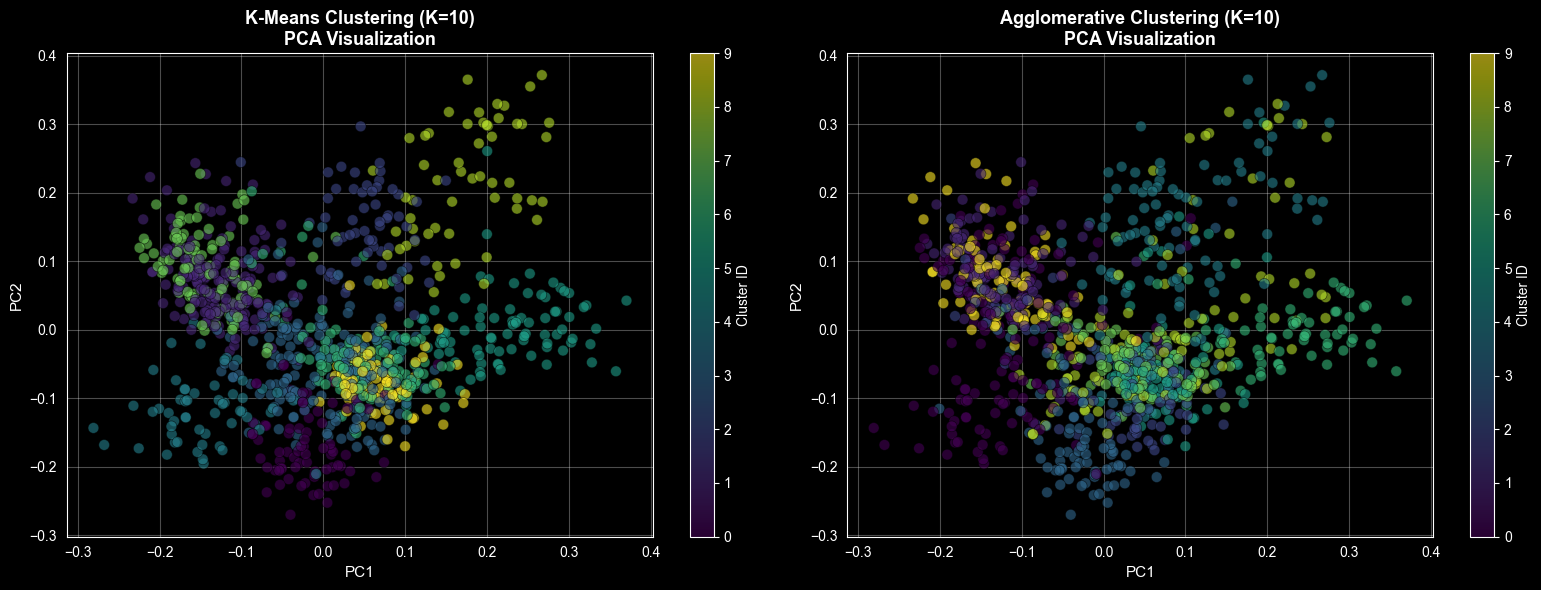

✓ PCA visualization comparison complete


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    tfidf_pca_10d[:, 0],
    tfidf_pca_10d[:, 1],
    c=cluster_labels_final,
    cmap='viridis',
    s=60,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
axes[0].set_title('K-Means Clustering (K=10)\nPCA Visualization', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')

scatter2 = axes[1].scatter(
    tfidf_pca_10d[:, 0],
    tfidf_pca_10d[:, 1],
    c=hc_labels,
    cmap='viridis',
    s=60,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
axes[1].set_title('Agglomerative Clustering (K=10)\nPCA Visualization', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC2', fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')

plt.tight_layout()
plt.show()

print("✓ PCA visualization comparison complete")


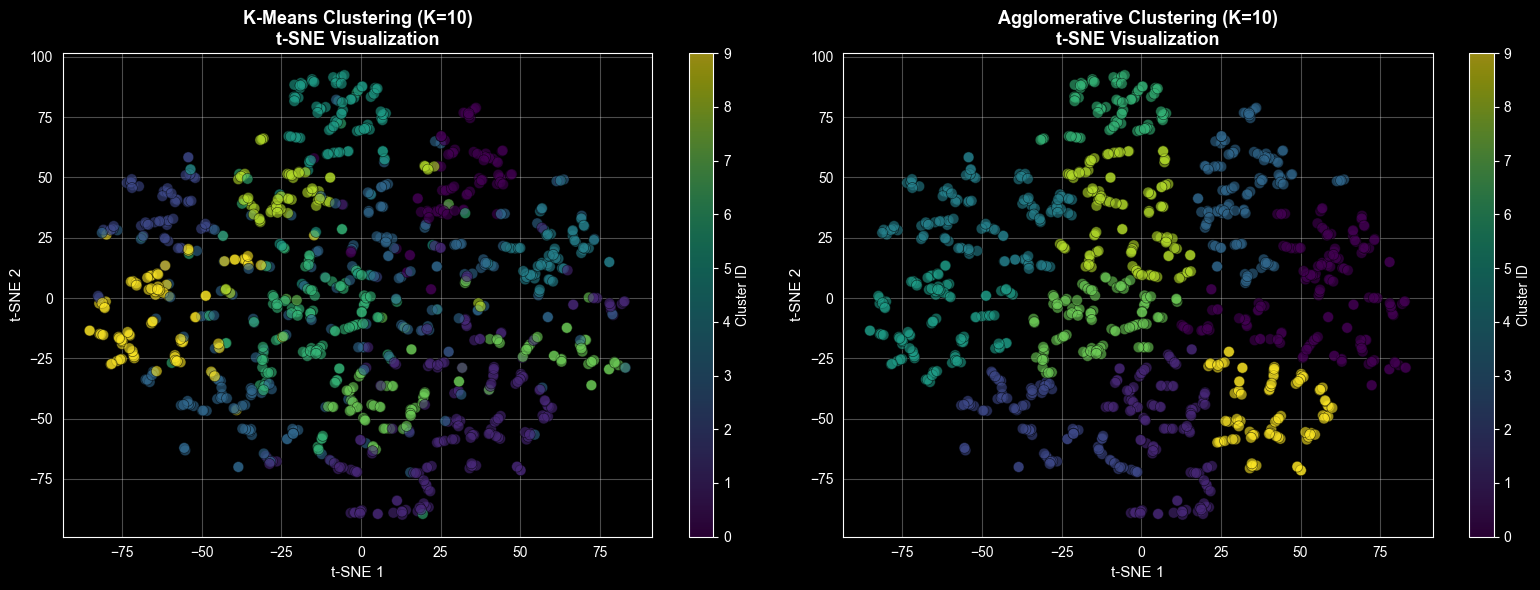

✓ t-SNE visualization comparison complete


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    tsne_2d_embedding[:, 0],
    tsne_2d_embedding[:, 1],
    c=cluster_labels_final,
    cmap='viridis',
    s=60,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
axes[0].set_title('K-Means Clustering (K=10)\nt-SNE Visualization', fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE 1', fontsize=11)
axes[0].set_ylabel('t-SNE 2', fontsize=11)
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')

scatter2 = axes[1].scatter(
    tsne_2d_embedding[:, 0],
    tsne_2d_embedding[:, 1],
    c=hc_labels,
    cmap='viridis',
    s=60,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
axes[1].set_title('Agglomerative Clustering (K=10)\nt-SNE Visualization', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')

plt.tight_layout()
plt.show()

print("✓ t-SNE visualization comparison complete")


# Part 7 : Put the cluster color for each sentences


---
## Objective :
##### Create a list and a csv, to see and save the result of our data clustering,
##### then we can see each cluster's sentences

## Result :
##### We can see the result in the output file named ``final_result.csv`` in the folder "Unsupervised _Part"

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

n_clusters = 10
cmap = plt.get_cmap('viridis')

cluster_colors = [mcolors.to_hex(cmap(i / (n_clusters - 1))) for i in range(n_clusters)]

df_final = pd.DataFrame({
    'Sentences': testimonies_list,
    'Cluster_ID': hc_labels,
    'Color': [cluster_colors[label] for label in hc_labels]
})

df_final.to_csv(output_file, index=True, index_label="Index", encoding="utf-8")